Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))
Statevector([ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
            dims=(2, 2))
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]


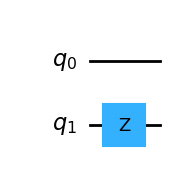

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit import QuantumRegister
# qiskit 所有的 tensor product 都是用 q_0 结尾的，然后输入的 label 的最后一位也是分配给 q_0
# 所以注意在使用矩阵表示算符的时候，q_1 是 tensor product 的倒数第二位
qreg = QuantumRegister(2, 'q')
qc = QuantumCircuit(qreg)
qc.z(qreg[1])

initial_state = Statevector.from_label('10')
final_state = initial_state.evolve(qc)
print(initial_state)
print(final_state)

from qiskit.quantum_info import Operator
# 获取幺正矩阵
Q = Operator(qc).data
print(Q)

qc.draw('mpl')

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter
from scipy.linalg import expm
from scipy.linalg import norm
import numpy as np
# customize quantum circuit for quantum simulation 
from qiskit import QuantumRegister
from qiskit.circuit.library import RZZGate, RXGate
from qiskit import transpile
from qiskit import qasm2, qasm3
import qiskit.version

print("Qiskit version:", qiskit.version.get_version_info())

# 参数
n = 9       # 自旋数
J = 0.5     # 相互作用强度
h = 1.0     # 横场强度
t = 1     # 演化时间

# 定义 Pauli 矩阵
X = np.array([[0, 1], [1, 0]])  # Pauli-X 矩阵
Y = np.array([[0, -1j], [1j, 0]])  # Pauli-Y 矩阵
Z = np.array([[1, 0], [0, -1]])  # Pauli-Z 矩阵
I = np.eye(2)  # 单位矩阵


def kron_all(ops):
    """对列表中的算符依次做 Kronecker 积"""
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out

def ZZ(n, i, j):
    """
    返回 n 比特体系上的 Z_i Z_j（其余位为 I）。
    约定：比特 0 在最左侧（k 从 0 到 n-1 依次张量）。
    """
    if not (0 <= i < n and 0 <= j < n):
        raise ValueError("i, j 必须在 [0, n-1] 范围内")
    ops = []
    for k in range(n):
        if k == n-1-i or k == n-1-j: # 反过来从而和 qiskit 对齐
            ops.append(Z)
        else:
            ops.append(I)
    return kron_all(ops)
        
# 9 比特
n = 9

# 构建各项
H_1 = - (ZZ(n, 1, 2) + ZZ(n, 0, 8) + ZZ(n, 3, 4))
H_2 = - (ZZ(n, 0, 1) + ZZ(n, 4, 6) + ZZ(n, 7, 8))
H_3 = - (ZZ(n, 1, 3) + ZZ(n, 4, 5) + ZZ(n, 6, 8))

H_e = np.zeros((2**n, 2**n), dtype=complex)
# 添加外部磁场项 (σx)s
for i in range(n):
    field_term = np.kron(np.eye(2**i), np.kron(X, np.eye(2**(n-i-1))))
    H_e += -h * field_term

H = J * (H_1 + H_2 + H_3) + H_e

np.save('Ising_Hamiltonian.npy', H)
U = expm(-1j * H * t)

# spectral norm of U
norm(U, ord=2)

Qiskit version: 2.1.0


1.0000000000000018

In [4]:
r_scale = 2  # Trotter 步数缩放因子
r_list = []

choice = 'well'

if choice == 'well':
    r_list = r_scale * np.array([1, 2, 6])
    b_list = [1/105, -1/6, 81/70]

    r_list = r_scale * np.array([1, 2, 3, 10])
    b_list = [-1/2376, 2/45, -729/3640, 31250/27027]

    r_list = r_scale * np.array([1, 2, 3, 5, 17])
    b_list = [1/165888, -256/89775, 6561/179200, -390625/2128896, 6975757441/6067353600]
    
    m = len(r_list)  # Interpolation number
    s_list = t / np.array(r_list) # 每个 Trotter 步的演化时间
    
else:
    eta = 2.0  # 外插叠加系数
    m = 3 # Interpolation number
    for i in range(1, m + 1):
        # 计算 Trotter 步数
        r = r_scale * np.ceil((np.sqrt(8) * m / np.pi) / np.sin(np.pi * (2 * i - 1) / (8 * m)))
        r_list.append(int(r))
        r_list.reverse()

    s_list = t / np.array(r_list) # 每个 Trotter 步的演化时间

    b_list = np.ones(m)  # 外插叠加系数

    for i in range(m):
        for j in range(m):
            if j != i:
                b_list[i] *= s_list[j]**eta / (s_list[j]**eta - s_list[i]**eta)

print('Trotter Step:', r_list)
print('Coefficients:', b_list)

Trotter Step: [ 2  4  6 10 34]
Coefficients: [6.028163580246913e-06, -0.0028515733778891675, 0.036612723214285714, -0.18348712196368447, 1.1497199439637076]


In [12]:
r_list = [100]
qc_list = []  # 量子电路列表

for r in r_list:
    # 创建一个有 5 个量子比特的寄存器
    qreg = QuantumRegister(9, 'q')
    qc = QuantumCircuit(qreg)
    for i in range(r):
        rx_angle = - h * t / r
        if i == 0:
            qc.rx(rx_angle, qreg)
            qc.barrier()
        
        zz_angle = - J * t / r
        # 添加一层 ZZ(-0.05) 门
        qc.append(RZZGate(2 * zz_angle), [qreg[1], qreg[2]])
        qc.append(RZZGate(2 * zz_angle), [qreg[0], qreg[8]])
        qc.append(RZZGate(2 * zz_angle), [qreg[3], qreg[4]])
        qc.barrier()
        
        # 合并一层 ZZ(-0.05) 门
        qc.append(RZZGate(2 * zz_angle), [qreg[0], qreg[1]])
        qc.append(RZZGate(2 * zz_angle), [qreg[4], qreg[6]])
        qc.append(RZZGate(2 * zz_angle), [qreg[7], qreg[8]])
        qc.barrier()
        
        # 添加一层 ZZ(-0.05) 门
        qc.append(RZZGate(2 * zz_angle), [qreg[1], qreg[3]])
        qc.append(RZZGate(2 * zz_angle), [qreg[4], qreg[5]])
        qc.append(RZZGate(2 * zz_angle), [qreg[6], qreg[8]])
        qc.barrier()
        
        
        # 合并层 RX(-0.1) 门
        if i == r - 1:
            qc.rx(rx_angle, qreg)
            qc.barrier()
        else:
            qc.rx(2 * rx_angle, qreg)
            qc.barrier()
        

    # 转换电路以适应特定的量子设备
    # qc = transpile(qc, basis_gates=['cz', 'h', 'rz'])
    qc_list.append(qc)
     
    # 展开电路并导出为 QASM 文件
    dump = 2
    
    if dump == 2:
        with open(f"./qasm2/Ising_r_{r}.qasm", "w") as f:
            f.write(qasm2.dumps(qc))
    elif dump == 3:
        with open(f"./qasm3/Ising_r_{r}.qasm", "w") as f:
            f.write(qasm3.dumps(qc))
    
# 创建一个初始态，这里以 |0...1⟩ 初始态为例
initial_state = Statevector.from_label('0' * (n - 1) + '1') 
psi0 = initial_state.data

# print("initial error: ", np.linalg.norm(initial_state.data - psi0), end ='\n')
# 演化：ψ(t) = e^{-iHt} ψ(0)
psi_t = U @ psi0

qc = qc_list[0]
final_state = initial_state.evolve(qc)
print(f"Trotter step: {r}") # , {final_state.data[0]}")
print(f'Simulation error between final state: ', np.linalg.norm(final_state.data - psi_t), end ='\n')
print(f'Overlap between final state: ', np.abs(np.vdot(final_state.data, psi_t)), end ='\n')
# 计算每个 Trotter 步数下的最终态

    # qc.measure_all()
    
    # pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    # isa_circuit = pm.run(qc)
    # 
    # sampler = Sampler(backend)
    # job = sampler.run([isa_circuit])
    # result = job.result()
    # print(f" > Counts: {result[0].data.meas.get_counts()}")
    
# qc_list[0].draw('mpl')

Trotter step: 100
Simulation error between final state:  4.844547650785077e-05
Overlap between final state:  0.9999999990766069


In [ ]:
# 定义全局和局部磁化算符
# qiskit 里的 q 顺序是反的，所以这里的 Z 其实作用在 q_4 上
local_mag = np.kron(Z, np.kron(I, np.kron(I, np.kron(I, I))))  
global_mag = np.kron(Z, np.kron(Z, np.kron(Z, np.kron(Z, Z))))  # Z^5

# 创建一个初始态，这里以 |0...1⟩ 初始态为例
initial_state = Statevector.from_label('0' * (n - 1) + '1') 
psi0 = initial_state.data

# 演化：ψ(t) = e^{-iHt} ψ(0)
psi_t = U @ psi0

# np.vdot(psi0, np.dot(local_mag, psi0))
print("ideal local magnetization:", np.abs(np.vdot(psi_t, np.dot(local_mag, psi_t))))

def Trotter_Unitary(r):
    U_r = expm(-1j * H1 * t / (2 * r)) @ expm(-1j * H2 * t / (2 * r)) @ expm(-1j * H3 * t / r) @ expm(-1j * H2 * t / (2 * r)) @ expm(-1j * H1 * t / (2 * r))
    U = np.identity(2**n, dtype=complex)
    for i in range(r):
        U = U @ U_r
    return U

sum_l = 0
for i in range(len(r_list)):
    psi_matrix = Trotter_Unitary(r_list[i]) @ psi0
    observable = np.vdot(psi_matrix, np.dot(local_mag, psi_matrix))
    # print(norm(Trotter_Unitary(r_list[i])- expm(-1j * H * t), ord=2), end ='\n')
    print(f"r = {r_list[i]}, exact local magnetization: {np.abs(observable)}")
    sum_l += b_list[i] * np.abs(observable)
    
print(f"MPF ideal local magnetization: {sum_l}")

# 这里和下面不一样是因为 t 被换成了 1.0, 0.1 的时候才是 0.99 几

ideal local magnetization: 0.3107385662547188
r = 2, ideal local magnetization: 0.27237742885542743
r = 4, ideal local magnetization: 0.3018250671631699
r = 6, ideal local magnetization: 0.3068279508485742
r = 10, ideal local magnetization: 0.30933994455895336
r = 34, ideal local magnetization: 0.31061798293314946
MPF ideal local magnetization: 0.3107385662447123
